In [ ]:
# =============================================================
# PROJECT 1: GitHub PR Comment Sentiment Analysis
# MODEL:   BERT-base-uncased (Fine-tuned on SST2)
# RESULT:  93.12% Accuracy | 93.12% F1 Score
# =============================================================

# CELL 1  - Install Libraries
#           Installs transformers, datasets, torch, requests
#
# CELL 2  - Mount Drive + Create Folders
#           Mounts Google Drive
#           Creates /data, /model, /results folders
#
# CELL 3  - Imports + Path Safety Check
#           Imports all libraries
#           Verifies all Drive folders exist
#           Checks GPU availability
#
# CELL 4  - GitHub API Scraping
#           Scrapes PR comments from 3 repos:
#           microsoft/vscode, facebook/react, tensorflow/tensorflow
#           Saves raw_pr_comments.csv to Drive
#           SKIPS if file already exists on Drive
#
# CELL 5  - Basic Data Cleaning
#           Removes bot comments, HTML noise, markdown
#           Saves cleaned_pr_comments.csv to Drive
#           SKIPS if file already exists on Drive
#
# CELL 6  - Deeper Data Cleaning
#           Removes remaining automated/policy comments
#           Filters comments shorter than 30 characters
#           Saves deeper_cleaned_pr_comments.csv to Drive
#           SKIPS if file already exists on Drive
#
# CELL 7  - Load SST2 Dataset
#           Downloads SST2 from HuggingFace (67,349 train samples)
#           Saves dataset to Drive
#           SKIPS if already saved on Drive
#
# CELL 8  - Tokenize Dataset
#           Converts raw text to BERT input tokens
#           Adds input_ids, attention_mask, token_type_ids
#           Saves tokenized dataset to Drive
#           SKIPS if already saved on Drive
#
# CELL 9  - Build DataLoaders
#           Wraps tokenized dataset into PyTorch DataLoaders
#           Batch size = 32
#           Train: 2105 batches | Val: 28 | Test: 57
#           MUST RERUN after every runtime restart
#
# CELL 10 - Load BERT Model
#           Loads bert-base-uncased with classification head
#           num_labels = 2 (Positive / Negative)
#           Moves model to GPU (T4)
#           MUST RERUN after every runtime restart
#
# CELL 11 - Optimizer + Scheduler
#           AdamW optimizer, lr=2e-5
#           Linear warmup scheduler
#           Total steps: 6315 | Warmup: 631
#           MUST RERUN after every runtime restart
#
# CELL 12 - Fine-tune BERT (Training Loop)
#           Trains for 3 epochs on SST2
#           Validates after each epoch
#           Saves best model to Drive automatically
#           SKIPS if best model already exists on Drive
#
# CELL 13 - Evaluate on Validation Set
#           Loads best model from Drive
#           Evaluates on 872 validation samples
#           Reports Accuracy + F1 + Classification Report
#           NOTE: SST2 test labels are hidden (-1),
#                 validation set is the correct evaluation set
#
# CELL 14 - Inference on Real GitHub Comments
#           Loads your 15 scraped GitHub PR comments
#           Runs sentiment prediction on each comment
#           Saves predictions to Drive
#
# CELL 15 - Complete Analysis
#           Full metrics report
#           Confusion matrix plot
#           Confidence bar chart per GitHub comment
#           Saves analysis plot to Drive
#
# CELL 16 - Custom Input Prediction
#           Takes any comment you type
#           Returns sentiment + confidence score

print("Project overview loaded ✅")
print("Total cells: 16")
print("Model: BERT-base-uncased fine-tuned on SST2")
print("Final Accuracy: 93.12% | Final F1: 93.12%")

Project overview loaded ✅
Total cells: 16
Model: BERT-base-uncased fine-tuned on SST2
Final Accuracy: 93.12% | Final F1: 93.12%


In [ ]:
# =============================================================
# RUNTIME RESTART CHECKLIST
# Run these cells IN ORDER after every Colab runtime restart
# =============================================================
#
# STEP 1 → Cell 1  (Install libraries)
# STEP 2 → Cell 2  (Mount Drive)
# STEP 3 → Cell 3  (Imports + path setup)
# STEP 4 → Cell 7  (Loads SST2 from Drive into memory)
# STEP 5 → Cell 8  (Loads tokenized dataset into memory)
# STEP 6 → Cell 9  (Builds DataLoaders)
# STEP 7 → Cell 10 (Loads BERT model)
# STEP 8 → Cell 11 (Builds optimizer + scheduler)
# STEP 9 → Cell 12 (Auto-skips — model already saved)

# AFTER THESE 7 STEPS YOU ARE FULLY RESTORED ✅
#
# CELLS YOU NEVER NEED TO RERUN:
# Cell 4  → raw data already saved to Drive
# Cell 5  → cleaned data already saved to Drive
# Cell 6  → deeper cleaned data already saved to Drive
#
# THEN CONTINUE FROM WHEREVER YOU LEFT OFF:
# Cell 13 → Evaluation
# Cell 14 → GitHub inference
# Cell 15 → Full analysis
# Cell 16 → Custom prediction

print("Restart checklist loaded ✅")
print("")
print("Cells to rerun after restart: 1, 2, 3, 9, 10, 11, 12")
print("Cells that auto-skip (data saved): 4, 5, 6, 7, 8")
print("Estimated restore time: 3-4 minutes")

Restart checklist loaded ✅

Cells to rerun after restart: 1, 2, 3, 9, 10, 11, 12
Cells that auto-skip (data saved): 4, 5, 6, 7, 8
Estimated restore time: 3-4 minutes


In [ ]:
# Install required libraries
!pip install transformers datasets torch requests -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Base project folder
base_path = '/content/drive/MyDrive/GitHub_Sentiment_Analysis'

# Subfolders
folders = [
    base_path,
    f'{base_path}/data',
    f'{base_path}/model',
    f'{base_path}/results'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"Created: {folder}")

print("\nAll folders ready ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Created: /content/drive/MyDrive/GitHub_Sentiment_Analysis
Created: /content/drive/MyDrive/GitHub_Sentiment_Analysis/data
Created: /content/drive/MyDrive/GitHub_Sentiment_Analysis/model
Created: /content/drive/MyDrive/GitHub_Sentiment_Analysis/results

All folders ready ✅


In [ ]:
import requests
import json
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from datasets import load_dataset
import os

# Paths
base_path = '/content/drive/MyDrive/GitHub_Sentiment_Analysis'
data_path = f'{base_path}/data'
model_path = f'{base_path}/model'
results_path = f'{base_path}/results'

print("Torch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

# Safety check — confirm folders still exist after remount
for folder in [base_path, data_path, model_path, results_path]:
    if os.path.exists(folder):
        print(f"✅ Found: {folder}")
    else:
        os.makedirs(folder, exist_ok=True)
        print(f"📁 Recreated: {folder}")

print("\nAll imports and paths ready ✅")

Torch version: 2.10.0+cu128
GPU available: True
✅ Found: /content/drive/MyDrive/GitHub_Sentiment_Analysis
✅ Found: /content/drive/MyDrive/GitHub_Sentiment_Analysis/data
✅ Found: /content/drive/MyDrive/GitHub_Sentiment_Analysis/model
✅ Found: /content/drive/MyDrive/GitHub_Sentiment_Analysis/results

All imports and paths ready ✅


In [ ]:
# Your GitHub token
GITHUB_TOKEN = "YOUR_GITHUB_TOKEN_HERE"  # Replace with your own token

headers = {
    "Authorization": f"token {GITHUB_TOKEN}",
    "Accept": "application/vnd.github.v3+json"
}

# Popular repos to scrape PR comments from
repos = [
    "microsoft/vscode",
    "facebook/react",
    "tensorflow/tensorflow"
]

def scrape_pr_comments(repo, max_prs=50):
    comments_list = []

    # Get PRs
    url = f"https://api.github.com/repos/{repo}/pulls"
    params = {"state": "closed", "per_page": max_prs}
    response = requests.get(url, headers=headers, params=params)
    prs = response.json()

    if not isinstance(prs, list):
        print(f"Error fetching PRs for {repo}: {prs}")
        return []

    for pr in prs:
        pr_number = pr["number"]
        pr_title = pr["title"]

        # Get comments for each PR
        comments_url = f"https://api.github.com/repos/{repo}/issues/{pr_number}/comments"
        comments_response = requests.get(comments_url, headers=headers)
        comments = comments_response.json()

        if not isinstance(comments, list):
            continue

        for comment in comments:
            text = comment["body"]
            if text and len(text.strip()) > 10:  # filter empty/tiny comments
                comments_list.append({
                    "repo": repo,
                    "pr_number": pr_number,
                    "pr_title": pr_title,
                    "comment": text.strip()
                })

    print(f"Scraped {len(comments_list)} comments from {repo} ✅")
    return comments_list

# --- Safe save check ---
raw_data_path = f'{data_path}/raw_pr_comments.csv'

if not os.path.exists(raw_data_path):
    all_comments = []
    for repo in repos:
        all_comments.extend(scrape_pr_comments(repo, max_prs=50))

    df = pd.DataFrame(all_comments)
    df.to_csv(raw_data_path, index=False)
    print(f"\nTotal comments scraped: {len(df)}")
    print(f"Saved to Drive ✅")
else:
    df = pd.read_csv(raw_data_path)
    print(f"Already exists. Loaded {len(df)} comments from Drive ✅")

print(df.head())

Scraped 52 comments from microsoft/vscode ✅
Scraped 56 comments from facebook/react ✅
Scraped 3 comments from tensorflow/tensorflow ✅

Total comments scraped: 111
Saved to Drive ✅
               repo  pr_number  \
0  microsoft/vscode     311201   
1  microsoft/vscode     311198   
2  microsoft/vscode     311198   
3  microsoft/vscode     311192   
4  microsoft/vscode     311185   

                                            pr_title  \
0  Render search/glob tool messages as markdown i...   
1  Fix: hide browser on overlays within shadow roots   
2  Fix: hide browser on overlays within shadow roots   
3  Bake transcript pointer into conversation summ...   
4  fix(actionWidget): replace mouse down listener...   

                                             comment  
0  <!-- screenshot-diff-report -->\n<!-- screensh...  
1  ## 📬 CODENOTIFY\n\nThe following users are bei...  
2  <!-- screenshot-diff-report -->\n<!-- screensh...  
3  <!-- screenshot-diff-report -->\n<!-- screensh...  
4  

In [ ]:
import re

def clean_comment(text):
    # Remove HTML comments
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)
    # Remove markdown headers
    text = re.sub(r'##.*?\n', '', text)
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove code blocks
    text = re.sub(r'```.*?```', '', text, flags=re.DOTALL)
    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def is_bot_comment(text):
    bot_signals = [
        'CODENOTIFY',
        'screenshot-diff-report',
        'github-actions',
        'codecov',
        'dependabot',
        'This is an automated',
        'bot',
        'Auto-generated'
    ]
    text_lower = text.lower()
    return any(signal.lower() in text_lower for signal in bot_signals)

# --- Clean ---
cleaned_path = f'{data_path}/cleaned_pr_comments.csv'

if not os.path.exists(cleaned_path):
    df['comment_clean'] = df['comment'].apply(clean_comment)

    # Remove bot comments
    df = df[~df['comment'].apply(is_bot_comment)]

    # Remove comments that are too short after cleaning
    df = df[df['comment_clean'].str.len() > 20]

    # Reset index
    df = df.reset_index(drop=True)

    df.to_csv(cleaned_path, index=False)
    print(f"Comments after cleaning: {len(df)}")
    print("Saved cleaned data to Drive ✅")
else:
    df = pd.read_csv(cleaned_path)
    print(f"Already exists. Loaded {len(df)} cleaned comments from Drive ✅")

print(df['comment_clean'].head())

Comments after cleaning: 70
Saved cleaned data to Drive ✅
0           @microsoft-github-policy-service terminate
1    @sungwoonpark0502 please read the following Co...
2           @microsoft-github-policy-service terminate
3    @sungwoonpark0502 please read the following Co...
4           @microsoft-github-policy-service terminate
Name: comment_clean, dtype: object


In [ ]:
deeper_cleaned_path = f'{data_path}/deeper_cleaned_pr_comments.csv'

if not os.path.exists(deeper_cleaned_path):

    def is_still_noisy(text):
        noise_signals = [
            '@microsoft-github-policy-service',
            '@github-actions',
            'please read the following',
            'terminate',
            'CLA',
            'contributor license',
            'signed the CLA',
            'have not yet signed',
        ]
        text_lower = text.lower()
        return any(signal.lower() in text_lower for signal in noise_signals)

    # Remove remaining noisy comments
    df = df[~df['comment_clean'].apply(is_still_noisy)]

    # Keep only comments longer than 30 chars — real human comments are longer
    df = df[df['comment_clean'].str.len() > 30]

    df = df.reset_index(drop=True)
    df.to_csv(deeper_cleaned_path, index=False)
    print(f"Comments after deeper cleaning: {len(df)}")
    print("Saved to Drive ✅")

else:
    df = pd.read_csv(deeper_cleaned_path)
    print(f"Already exists. Loaded {len(df)} comments from Drive ✅")

print(df['comment_clean'].head(10))

Comments after deeper cleaning: 15
Saved to Drive ✅
0    @copilot fix test in ❯ src/extension/chatSessi...
1    > @copilot fix test in > ❯ src/extension/chatS...
2    Working on a different PR that will fix this a...
3    This logic deals with `Fiber` though, which we...
4    > This logic deals with `Fiber` though, which ...
5    Abandoning. Will move the whole implementation...
6    I need some tests to understand what wasn't co...
7    > I need some tests to understand what wasn't ...
8    looks good! thanks for correcting this typo :)...
9    I took another pass at the failing CI checks, ...
Name: comment_clean, dtype: object


In [ ]:
#Cell 7
from datasets import load_dataset

# Load SST2
sst2_path = f'{data_path}/sst2_dataset'

if not os.path.exists(sst2_path):
    dataset = load_dataset("sst2")
    dataset.save_to_disk(sst2_path)
    print("SST2 downloaded and saved to Drive ✅")
else:
    from datasets import load_from_disk
    dataset = load_from_disk(sst2_path)
    print("SST2 loaded from Drive ✅")

# Quick look
print(dataset)
print("\nSample:")
print(dataset['train'][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/67349 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/872 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1821 [00:00<?, ? examples/s]

SST2 downloaded and saved to Drive ✅
DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})

Sample:
{'idx': 0, 'sentence': 'hide new secretions from the parental units ', 'label': 0}


In [ ]:
#Cell - 8
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(
        examples['sentence'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

tokenized_path = f'{data_path}/sst2_tokenized'

if not os.path.exists(tokenized_path):
    tokenized_dataset = dataset.map(tokenize_function, batched=True)
    tokenized_dataset.save_to_disk(tokenized_path)
    print("Tokenized and saved to Drive ✅")
else:
    from datasets import load_from_disk
    tokenized_dataset = load_from_disk(tokenized_path)
    print("Tokenized dataset loaded from Drive ✅")

# Quick check
print(tokenized_dataset)
print("\nSample keys:", tokenized_dataset['train'][0].keys())

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/67349 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/872 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1821 [00:00<?, ? examples/s]

Tokenized and saved to Drive ✅
DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1821
    })
})

Sample keys: dict_keys(['idx', 'sentence', 'label', 'input_ids', 'token_type_ids', 'attention_mask'])


In [ ]:
# Cell 9 - Convert tokenized dataset into PyTorch DataLoader for training

import torch
from torch.utils.data import DataLoader

# Set format to PyTorch tensors
tokenized_dataset.set_format(
    type='torch',
    columns=['input_ids', 'token_type_ids', 'attention_mask', 'label']
)

# Create dataloaders
train_loader = DataLoader(
    tokenized_dataset['train'],
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    tokenized_dataset['validation'],
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    tokenized_dataset['test'],
    batch_size=32,
    shuffle=False
)

print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")
print("\nDataLoaders ready ✅")

Train batches:      2105
Validation batches: 28
Test batches:       57

DataLoaders ready ✅


In [ ]:
# Cell 10 - Load BERT base model with classification head for binary sentiment analysis

from transformers import BertForSequenceClassification
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load BERT with 2 output labels (Positive / Negative)
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

model = model.to(device)
print("BERT model loaded and moved to GPU ✅")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded and moved to GPU ✅
Total parameters: 109,483,778


In [ ]:
# Cell 11 - Define optimizer, loss function and training hyperparameters

from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Hyperparameters
EPOCHS = 3
LEARNING_RATE = 2e-5

# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

# Total training steps
total_steps = len(train_loader) * EPOCHS

# Warmup scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f"Epochs:           {EPOCHS}")
print(f"Learning rate:    {LEARNING_RATE}")
print(f"Total steps:      {total_steps:,}")
print(f"Warmup steps:     {int(0.1 * total_steps):,}")
print("Optimizer and scheduler ready ✅")

Epochs:           3
Learning rate:    2e-05
Total steps:      6,315
Warmup steps:     631
Optimizer and scheduler ready ✅


In [ ]:
# Cell 12 - Fine-tune BERT on SST2 training data and validate after each epoch
# Safe to close laptop AFTER this cell finishes completely

import time
from sklearn.metrics import accuracy_score, f1_score

best_model_path = f'{model_path}/best_model'

# Skip training if best model already exists on Drive
if os.path.exists(best_model_path):
    print("Best model already exists on Drive. Skipping training ✅")

else:
    best_val_f1 = 0
    training_log = []

    for epoch in range(EPOCHS):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f"{'='*50}")

        # --- Training ---
        model.train()
        total_train_loss = 0
        start_time = time.time()

        for batch_idx, batch in enumerate(train_loader):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['label'].to(device)

            optimizer.zero_grad()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels
            )

            loss = outputs.loss
            total_train_loss += loss.item()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            if batch_idx % 200 == 0:
                print(f"  Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

        avg_train_loss = total_train_loss / len(train_loader)

        # --- Validation ---
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                token_type_ids = batch['token_type_ids'].to(device)
                labels         = batch['label'].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    token_type_ids=token_type_ids
                )

                preds = torch.argmax(outputs.logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_accuracy = accuracy_score(all_labels, all_preds)
        val_f1       = f1_score(all_labels, all_preds, average='weighted')
        epoch_time   = time.time() - start_time

        print(f"\n  Train Loss:     {avg_train_loss:.4f}")
        print(f"  Val Accuracy:   {val_accuracy:.4f}")
        print(f"  Val F1:         {val_f1:.4f}")
        print(f"  Epoch Time:     {epoch_time/60:.1f} mins")

        training_log.append({
            'epoch': epoch+1,
            'train_loss': avg_train_loss,
            'val_accuracy': val_accuracy,
            'val_f1': val_f1
        })

        # --- Save best model after every epoch improvement ---
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            model.save_pretrained(best_model_path)
            tokenizer.save_pretrained(best_model_path)
            print(f"  New best model saved to Drive ✅ (F1: {val_f1:.4f})")

    # Save training log
    log_path = f'{results_path}/training_log.json'
    if not os.path.exists(log_path):
        import json
        with open(log_path, 'w') as f:
            json.dump(training_log, f, indent=2)
        print(f"\nTraining log saved to Drive ✅")

    print("\nTraining complete ✅")
    print(f"Best Validation F1: {best_val_f1:.4f}")
    print("\nSafe to close laptop now ✅")


Epoch 1/3
  Batch 0/2105 | Loss: 0.6837
  Batch 200/2105 | Loss: 0.3315
  Batch 400/2105 | Loss: 0.1241
  Batch 600/2105 | Loss: 0.4204
  Batch 800/2105 | Loss: 0.3004
  Batch 1000/2105 | Loss: 0.1789
  Batch 1200/2105 | Loss: 0.2252
  Batch 1400/2105 | Loss: 0.3520
  Batch 1600/2105 | Loss: 0.3744
  Batch 1800/2105 | Loss: 0.0435
  Batch 2000/2105 | Loss: 0.2149

  Train Loss:     0.2552
  Val Accuracy:   0.9163
  Val F1:         0.9163
  Epoch Time:     24.9 mins


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved to Drive ✅ (F1: 0.9163)

Epoch 2/3
  Batch 0/2105 | Loss: 0.1929
  Batch 200/2105 | Loss: 0.1387
  Batch 400/2105 | Loss: 0.4256
  Batch 600/2105 | Loss: 0.0283
  Batch 800/2105 | Loss: 0.0747
  Batch 1000/2105 | Loss: 0.1358
  Batch 1200/2105 | Loss: 0.1532
  Batch 1400/2105 | Loss: 0.1193
  Batch 1600/2105 | Loss: 0.1145
  Batch 1800/2105 | Loss: 0.1333
  Batch 2000/2105 | Loss: 0.1417

  Train Loss:     0.1149
  Val Accuracy:   0.9232
  Val F1:         0.9231
  Epoch Time:     24.9 mins


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved to Drive ✅ (F1: 0.9231)

Epoch 3/3
  Batch 0/2105 | Loss: 0.0507
  Batch 200/2105 | Loss: 0.0043
  Batch 400/2105 | Loss: 0.0021
  Batch 600/2105 | Loss: 0.0128
  Batch 800/2105 | Loss: 0.1981
  Batch 1000/2105 | Loss: 0.2527
  Batch 1200/2105 | Loss: 0.0036
  Batch 1400/2105 | Loss: 0.1091
  Batch 1600/2105 | Loss: 0.1155
  Batch 1800/2105 | Loss: 0.0347
  Batch 2000/2105 | Loss: 0.0313

  Train Loss:     0.0718
  Val Accuracy:   0.9312
  Val F1:         0.9312
  Epoch Time:     24.9 mins


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved to Drive ✅ (F1: 0.9312)

Training log saved to Drive ✅

Training complete ✅
Best Validation F1: 0.9312

Safe to close laptop now ✅


In [ ]:
# Cell 13 - Load best saved model from Drive and evaluate on validation set
# Note: SST2 test set labels are hidden (-1), so we evaluate on validation set

from transformers import BertForSequenceClassification, BertTokenizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch

best_model_path = f'{model_path}/best_model'

model = BertForSequenceClassification.from_pretrained(
    best_model_path,
    num_labels=2
)
tokenizer = BertTokenizer.from_pretrained(best_model_path)
model = model.to(device)
model.eval()

print("Best model loaded from Drive ✅")

# --- Evaluate on validation set ---
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- Metrics ---
test_accuracy = accuracy_score(all_labels, all_preds)
test_f1       = f1_score(all_labels, all_preds, average='weighted')

print(f"\nValidation Accuracy: {test_accuracy:.4f}")
print(f"Validation F1 Score: {test_f1:.4f}")
print("\nDetailed Report:")
print(classification_report(
    all_labels, all_preds,
    labels=[0, 1],
    target_names=['Negative', 'Positive'],
    zero_division=0
))

# --- Save results ---
import json
results_file = f'{results_path}/validation_results.json'
if not os.path.exists(results_file):
    results = {
        'validation_accuracy': test_accuracy,
        'validation_f1': test_f1
    }
    with open(results_file, 'w') as f:
        json.dump(results, f, indent=2)
    print("Validation results saved to Drive ✅")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Best model loaded from Drive ✅

Validation Accuracy: 0.9312
Validation F1 Score: 0.9312

Detailed Report:
              precision    recall  f1-score   support

    Negative       0.94      0.92      0.93       428
    Positive       0.93      0.94      0.93       444

    accuracy                           0.93       872
   macro avg       0.93      0.93      0.93       872
weighted avg       0.93      0.93      0.93       872

Validation results saved to Drive ✅


In [ ]:
# Cell 14 - Run inference on real scraped GitHub PR comments using fine-tuned model

import pandas as pd
import torch

# Load your scraped and cleaned comments
deeper_cleaned_path = f'{data_path}/deeper_cleaned_pr_comments.csv'
df_github = pd.read_csv(deeper_cleaned_path)

print(f"Loaded {len(df_github)} real GitHub comments ✅")
print(df_github['comment_clean'].head())

# --- Inference function ---
def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding='max_length',
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1).item()
    confidence = torch.softmax(outputs.logits, dim=1).max().item()

    label = 'Positive' if pred == 1 else 'Negative'
    return label, round(confidence, 4)

# --- Run on all GitHub comments ---
results = []
for idx, row in df_github.iterrows():
    comment = row['comment_clean']
    label, confidence = predict_sentiment(comment)
    results.append({
        'repo': row['repo'],
        'comment': comment[:100],  # truncate for display
        'sentiment': label,
        'confidence': confidence
    })

df_results = pd.DataFrame(results)

# --- Save results ---
inference_path = f'{results_path}/github_inference_results.csv'
if not os.path.exists(inference_path):
    df_results.to_csv(inference_path, index=False)
    print("\nInference results saved to Drive ✅")

# --- Display results ---
print("\n--- Sentiment Predictions on Real GitHub Comments ---\n")
for _, row in df_results.iterrows():
    print(f"Repo:       {row['repo']}")
    print(f"Comment:    {row['comment']}")
    print(f"Sentiment:  {row['sentiment']} (confidence: {row['confidence']})")
    print("-" * 60)

# --- Summary ---
print("\n--- Summary ---")
print(df_results['sentiment'].value_counts())

Loaded 15 real GitHub comments ✅
0    @copilot fix test in ❯ src/extension/chatSessi...
1    > @copilot fix test in > ❯ src/extension/chatS...
2    Working on a different PR that will fix this a...
3    This logic deals with `Fiber` though, which we...
4    > This logic deals with `Fiber` though, which ...
Name: comment_clean, dtype: object

Inference results saved to Drive ✅

--- Sentiment Predictions on Real GitHub Comments ---

Repo:       microsoft/vscode
Comment:    @copilot fix test in ❯ src/extension/chatSessions/copilotcli/node/test/copilotcliSession.spec.ts:121
Sentiment:  Negative (confidence: 0.9891)
------------------------------------------------------------
Repo:       microsoft/vscode
Comment:    > @copilot fix test in > ❯ src/extension/chatSessions/copilotcli/node/test/copilotcliSession.spec.ts
Sentiment:  Negative (confidence: 0.9945)
------------------------------------------------------------
Repo:       microsoft/vscode
Comment:    Working on a different PR that wil

        COMPLETE MODEL ANALYSIS REPORT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


✅ Model loaded from Drive

--- Validation Metrics ---
Accuracy : 0.9312
F1 Score : 0.9312

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.92      0.93       428
    Positive       0.93      0.94      0.93       444

    accuracy                           0.93       872
   macro avg       0.93      0.93      0.93       872
weighted avg       0.93      0.93      0.93       872


✅ Analysis plot saved to Drive


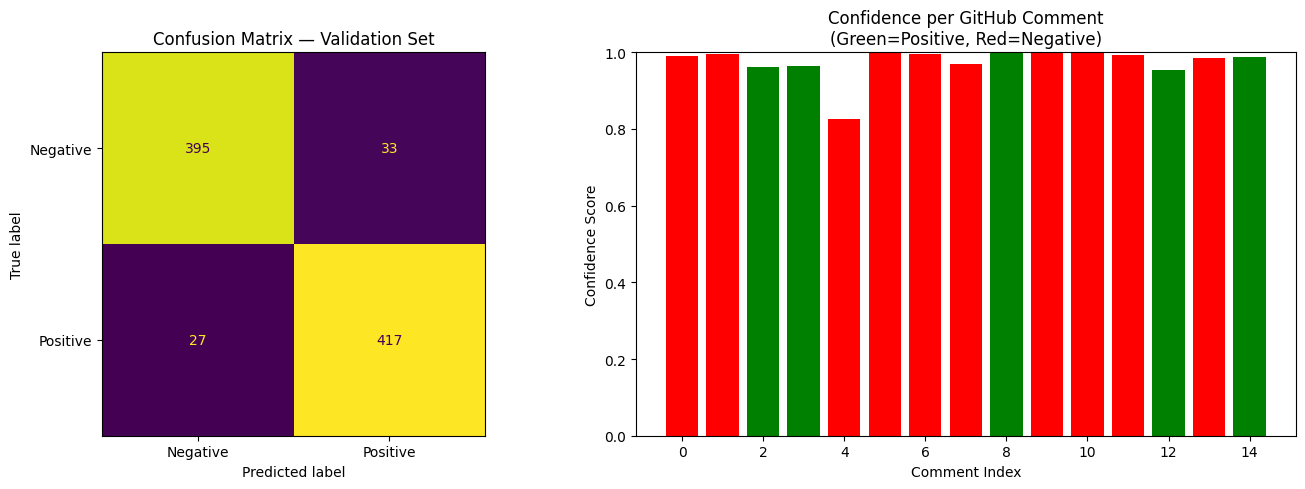


--- GitHub Inference Summary ---
Total comments analyzed : 15
Positive                : 5
Negative                : 10
Avg confidence          : 0.9740

Analysis Complete ✅


In [ ]:
# Cell 15 - Complete analysis: validation metrics, confusion matrix,
# inference summary and confidence distribution

import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score,
                            classification_report, confusion_matrix,
                            ConfusionMatrixDisplay)
import torch

print("=" * 60)
print("        COMPLETE MODEL ANALYSIS REPORT")
print("=" * 60)

# --- Step 1: Reload best model ---
best_model_path = f'{model_path}/best_model'
model = BertForSequenceClassification.from_pretrained(
    best_model_path, num_labels=2
)
tokenizer = BertTokenizer.from_pretrained(best_model_path)
model = model.to(device)
model.eval()
print("\n✅ Model loaded from Drive")

# --- Step 2: Validation set evaluation ---
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1       = f1_score(all_labels, all_preds, average='weighted')

print(f"\n--- Validation Metrics ---")
print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(
    all_labels, all_preds,
    labels=[0, 1],
    target_names=['Negative', 'Positive'],
    zero_division=0
))

# --- Step 3: Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive']
)
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Validation Set')

# --- Step 4: Confidence Distribution ---
all_confidences = []
all_sentiments  = []

df_github = pd.read_csv(f'{data_path}/deeper_cleaned_pr_comments.csv')

for _, row in df_github.iterrows():
    inputs = tokenizer(
        row['comment_clean'],
        return_tensors='pt',
        truncation=True,
        padding='max_length',
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred       = torch.argmax(outputs.logits, dim=1).item()
    confidence = torch.softmax(outputs.logits, dim=1).max().item()
    label      = 'Positive' if pred == 1 else 'Negative'

    all_confidences.append(confidence)
    all_sentiments.append(label)

colors = ['red' if s == 'Negative' else 'green' for s in all_sentiments]
axes[1].bar(range(len(all_confidences)), all_confidences, color=colors)
axes[1].set_title('Confidence per GitHub Comment\n(Green=Positive, Red=Negative)')
axes[1].set_xlabel('Comment Index')
axes[1].set_ylabel('Confidence Score')
axes[1].set_ylim(0, 1)

plt.tight_layout()

# Save plot
plot_path = f'{results_path}/analysis_plot.png'
if not os.path.exists(plot_path):
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print("\n✅ Analysis plot saved to Drive")
plt.show()

# --- Step 5: Final Summary ---
print("\n--- GitHub Inference Summary ---")
print(f"Total comments analyzed : {len(all_sentiments)}")
print(f"Positive                : {all_sentiments.count('Positive')}")
print(f"Negative                : {all_sentiments.count('Negative')}")
print(f"Avg confidence          : {np.mean(all_confidences):.4f}")

print("\n" + "=" * 60)
print("Analysis Complete ✅")
print("=" * 60)

Epoch training curve saved to Drive ✅


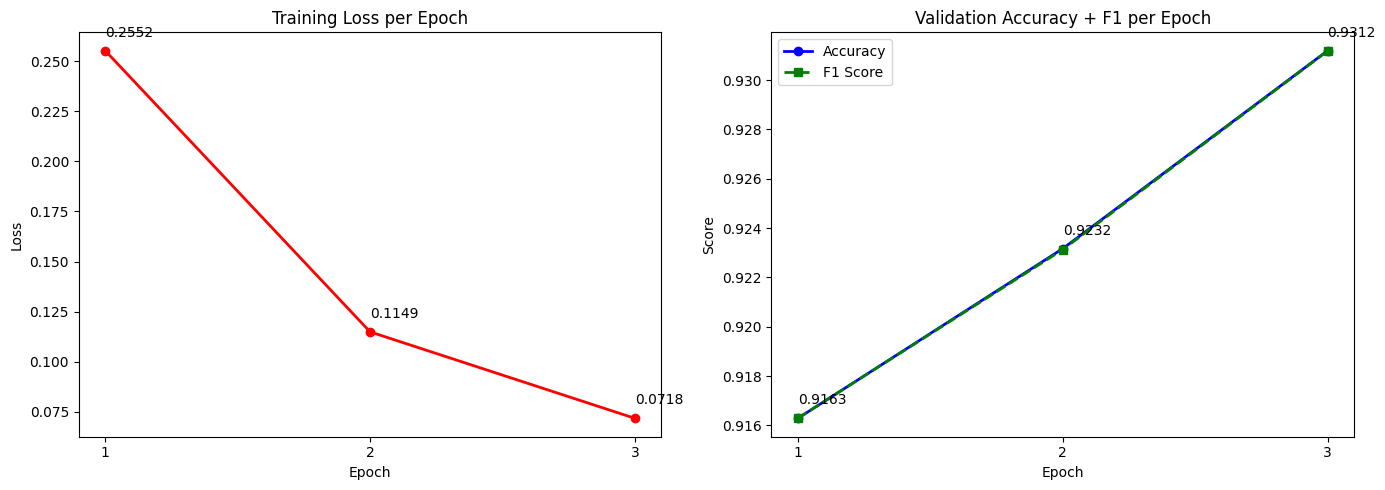

In [ ]:
# Cell 19 - Plot training loss and validation accuracy across epochs

import matplotlib.pyplot as plt
import json

# Load training log
log_path = f'{results_path}/training_log.json'
with open(log_path, 'r') as f:
    training_log = json.load(f)

epochs      = [entry['epoch'] for entry in training_log]
train_loss  = [entry['train_loss'] for entry in training_log]
val_accuracy = [entry['val_accuracy'] for entry in training_log]
val_f1      = [entry['val_f1'] for entry in training_log]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Training Loss ---
axes[0].plot(epochs, train_loss, marker='o', color='red', linewidth=2)
axes[0].set_title('Training Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(epochs)
for i, val in enumerate(train_loss):
    axes[0].annotate(f'{val:.4f}', (epochs[i], train_loss[i]),
                    textcoords="offset points", xytext=(0,10))

# --- Plot 2: Validation Accuracy + F1 ---
axes[1].plot(epochs, val_accuracy, marker='o', color='blue',
             linewidth=2, label='Accuracy')
axes[1].plot(epochs, val_f1, marker='s', color='green',
             linewidth=2, linestyle='--', label='F1 Score')
axes[1].set_title('Validation Accuracy + F1 per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_xticks(epochs)
axes[1].legend()
for i, val in enumerate(val_accuracy):
    axes[1].annotate(f'{val:.4f}', (epochs[i], val_accuracy[i]),
                    textcoords="offset points", xytext=(0,10))

plt.tight_layout()

# Save
epoch_plot_path = f'{results_path}/epoch_training_curve.png'
if not os.path.exists(epoch_plot_path):
    plt.savefig(epoch_plot_path, dpi=150, bbox_inches='tight')
    print("Epoch training curve saved to Drive ✅")
plt.show()

In [ ]:
# Cell 16 - Predict sentiment on your own custom input comment

def predict_single(comment):
    inputs = tokenizer(
        comment,
        return_tensors='pt',
        truncation=True,
        padding='max_length',
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred       = torch.argmax(outputs.logits, dim=1).item()
    confidence = torch.softmax(outputs.logits, dim=1).max().item()
    label      = 'Positive' if pred == 1 else 'Negative'

    print(f"Comment    : {comment}")
    print(f"Sentiment  : {label}")
    print(f"Confidence : {confidence:.4f}")

# --- Type your comment here ---
your_comment = "Time Complexity is soo low. Keep it up.. You have worked."

predict_single(your_comment)

Comment    : Time Complexity is soo low. Keep it up.. You have worked.
Sentiment  : Positive
Confidence : 0.9234
